# Exploratory Data Analysis - Study Case
- **Name:** Firman Adi Kurniawan
- **Email:** firmanadik09@gmail.com


# Business Questions
1. Compare behavior between churn and non-churn users.
2. Analyze session frequency, transaction amount, and feature usage.
3. Identify characteristics of users likely to churn.
4. Create simple segmentation: high-risk vs low-risk users.


# Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Chart Styling


In [3]:
plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
})

C_ACTIVE  = "#2c9cf1"
C_CHURN   = "#c81545"
C_ACCENT  = "#0e4062"
C_WARN    = "#f312d5"
PALETTE   = {"Active": C_ACTIVE, "Churn": C_CHURN}

# Load & Prepare Data


In [5]:
users        = pd.read_csv(r"C:\Users\asus3\Documents\UB - Copy\StudyCase_DatAnl\user.csv")
activity     = pd.read_csv(r"C:\Users\asus3\Documents\UB - Copy\StudyCase_DatAnl\activity.csv")
transactions = pd.read_csv(r"C:\Users\asus3\Documents\UB - Copy\StudyCase_DatAnl\transactions.csv")
status       = pd.read_csv(r"C:\Users\asus3\Documents\UB - Copy\StudyCase_DatAnl\status_clean.csv")

users["signup_date"]             = pd.to_datetime(users["signup_date"])
activity["event_date"]           = pd.to_datetime(activity["event_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
status["churn_date"]             = pd.to_datetime(status["churn_date"], errors="coerce")


# Feature Engineering


In [6]:
# aktivitas/user
act_feat = activity.groupby("user_id").agg(
    total_sessions = ("session_count", "sum"),
    avg_sessions   = ("session_count", "mean"),
    active_days    = ("event_date",    "nunique"),
    last_activity  = ("event_date",    "max"),
).reset_index()

# pivot
feat_usage = (
    activity.groupby(["user_id", "feature_used"])
    .size().unstack(fill_value=0).reset_index()
)
feat_usage.columns.name = None

# transaksi/user
trx_feat = transactions.groupby("user_id").agg(
    total_amount = ("amount", "sum"),
    avg_amount   = ("amount", "mean"),
    tx_count     = ("amount", "count"),
).reset_index()

# weekly sessions/user
activity["week_num"] = activity["event_date"].dt.isocalendar().week
weekly_user = activity.groupby(["user_id", "week_num"])["session_count"].sum().reset_index()
weekly_stat = weekly_user.groupby("user_id").agg(
    avg_weekly_sessions = ("session_count", "mean"),
    std_weekly_sessions = ("session_count", "std"),
    weeks_active        = ("week_num",      "nunique")
).reset_index()
weekly_stat["std_weekly_sessions"] = weekly_stat["std_weekly_sessions"].fillna(0)

# merge data master
df = (users
      .merge(status,      on="user_id")
      .merge(act_feat,    on="user_id", how="left")
      .merge(feat_usage,  on="user_id", how="left")
      .merge(trx_feat,    on="user_id", how="left")
      .merge(weekly_stat, on="user_id", how="left"))

df["churn_label"] = df["is_churn"].map({0: "Active", 1: "Churn"})
df = df.fillna(0)

print(f"  Dataset master : {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"  Churn          : {df['is_churn'].sum()} ({df['is_churn'].mean()*100:.1f}%)")
print(f"  Aktif          : {(df['is_churn']==0).sum()} ({(1-df['is_churn'].mean())*100:.1f}%)")

  Dataset master : 250 baris × 25 kolom
  Churn          : 74 (29.6%)
  Aktif          : 176 (70.4%)


# Descriptive Statistics


In [7]:
num_cols = [
    "total_sessions", "avg_sessions", "active_days",
    "avg_weekly_sessions", "weeks_active",
    "days_since_last_activity", "loan_count",
    "avg_transaction_amount", "total_amount", "tx_count",
    "browse", "loan_apply", "payment", "promo_click",
]

desc = df.groupby("churn_label")[num_cols].mean().round(2).T
desc["diff_pct"] = ((desc["Churn"] - desc["Active"]) / desc["Active"].replace(0, np.nan) * 100).round(1)
print("\n  Perbandingan Rata-rata Fitur: Active vs Churn")
print(desc.to_string())


  Perbandingan Rata-rata Fitur: Active vs Churn
churn_label                    Active        Churn  diff_pct
total_sessions                  35.55        35.88       0.9
avg_sessions                     2.99         3.07       2.7
active_days                     11.23        11.39       1.4
avg_weekly_sessions              4.09         4.19       2.4
weeks_active                     8.61         8.62       0.1
days_since_last_activity        42.11        54.91      30.4
loan_count                       4.36         3.34     -23.4
avg_transaction_amount     3554608.72   3448082.83      -3.0
total_amount              16483923.26  13246240.74     -19.6
tx_count                         4.36         3.34     -23.4
browse                           3.03         2.84      -6.3
loan_apply                       3.00         2.91      -3.0
payment                          3.01         2.77      -8.0
promo_click                      2.81         3.28      16.7


# 1. Compare Behavior Between Churn and Non-Churn Users
**H0_1:** Users who churn have already been showing signs of disengagement long before their churn status is officially recorded.

**H0_2:** User quality differs across acquisition channels — certain channels systematically produce less loyal users.

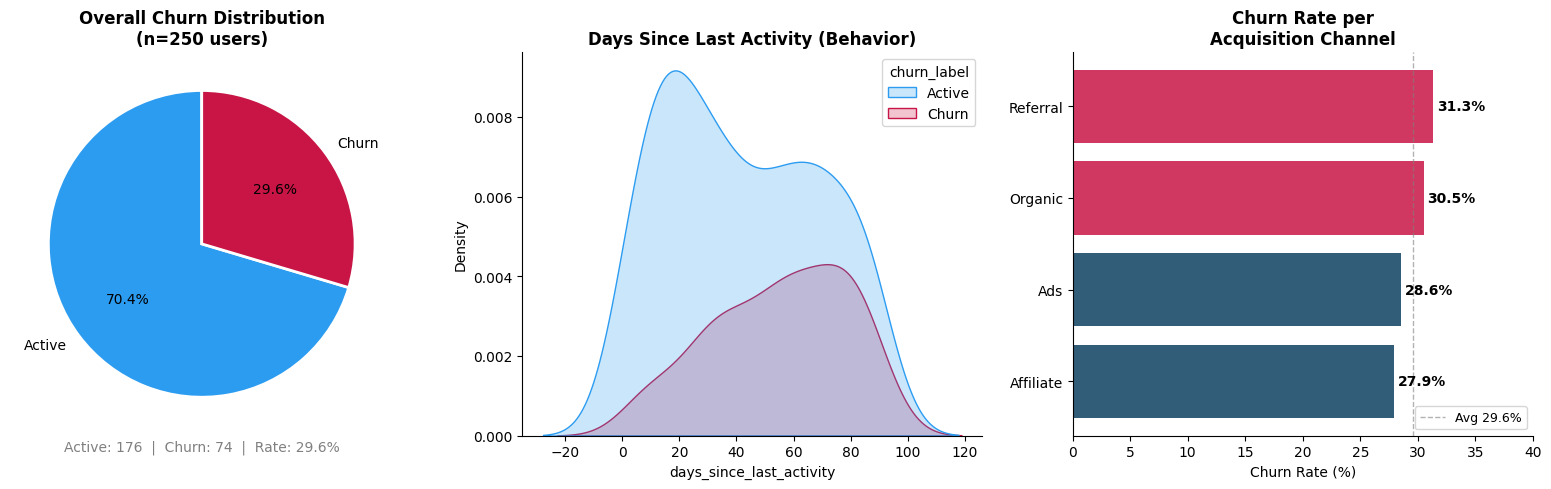

In [16]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5)) # Diperlebar menjadi 16x5 agar muat 3 grafik


ax = axes[0]
total  = len(df)
churn  = df['is_churn'].sum()
active = total - churn

ax.pie([active, churn],
       labels=['Active', 'Churn'],
       colors=[C_ACTIVE, C_CHURN],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Overall Churn Distribution\n(n=250 users)')
ax.text(0, -1.35, f'Active: {active}  |  Churn: {churn}  |  Rate: {(churn/total)*100:.1f}%',
        ha='center', fontsize=10, color='gray')


sns.kdeplot(data=df, x="days_since_last_activity", hue="churn_label", palette=PALETTE, fill=True, ax=axes[1])
axes[1].set_title("Days Since Last Activity (Behavior)")

ax = axes[2]
ch = (df.groupby('acquisition_channel')
        .agg(total=('user_id','count'), churn=('is_churn','sum'))
        .assign(churn_rate=lambda d: d.churn/d.total*100)
        .sort_values('churn_rate', ascending=True)
        .reset_index())
bars = ax.barh(ch['acquisition_channel'], ch['churn_rate'],
               color=[C_CHURN if r > 30 else C_ACCENT
                      for r in ch['churn_rate']], alpha=0.85)
for bar, val in zip(bars, ch['churn_rate']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(29.6, color='gray', linestyle='--', linewidth=1,
           alpha=0.6, label='Avg 29.6%')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate per\nAcquisition Channel')
ax.legend(fontsize=9); ax.set_xlim(0, 40)

plt.tight_layout()
plt.savefig("1_behavior_comparison.png", dpi=120)
plt.show()


# Insight

**[H0_1] Supported — Inactivity Is the Earliest Detectable Churn Signal**

Data: The median inactivity of Churn users is **58 days**, compared to only **38.5 days** for Active users (a gap of ~20 days). The KDE distributions begin to diverge noticeably at the 30-45 day mark.

Interpretation: Users who have not opened the app for more than **45 days** are already in the danger zone. This is an intervention window that has consistently been missed. Before churn is officially recorded, inactive behavior can already be detected early as a warning signal. A proactive re-engagement trigger at day 30 could prevent a large portion of churn.

---

**[H0_2] Supported — Referral Channel Produces the Lowest-Quality Users**

Data: Churn rate by channel: Referral **31.3%** (highest), Organic 30.5%, Ads 28.6%, Affiliate **27.9%** (lowest). The gap between Referral and Affiliate is 3.4 percentage points.

Interpretation: Users acquired through Referral are likely motivated by sign-up bonuses rather than a genuine financial need. Affiliate users arrive more organically and prove to be the most loyal. Business implication: acquisition budget should be reallocated away from Referral and toward Affiliate channels.

# 2. Analyze Session Frequency, Transaction Amount, and Feature Usage
**H0_1:** Churned users are those who rarely open the app, reflected by a lower average weekly session frequency.

**H0_2:** Churned users only visit the platform to chase short-term promotions and never build a habit of using its core features.

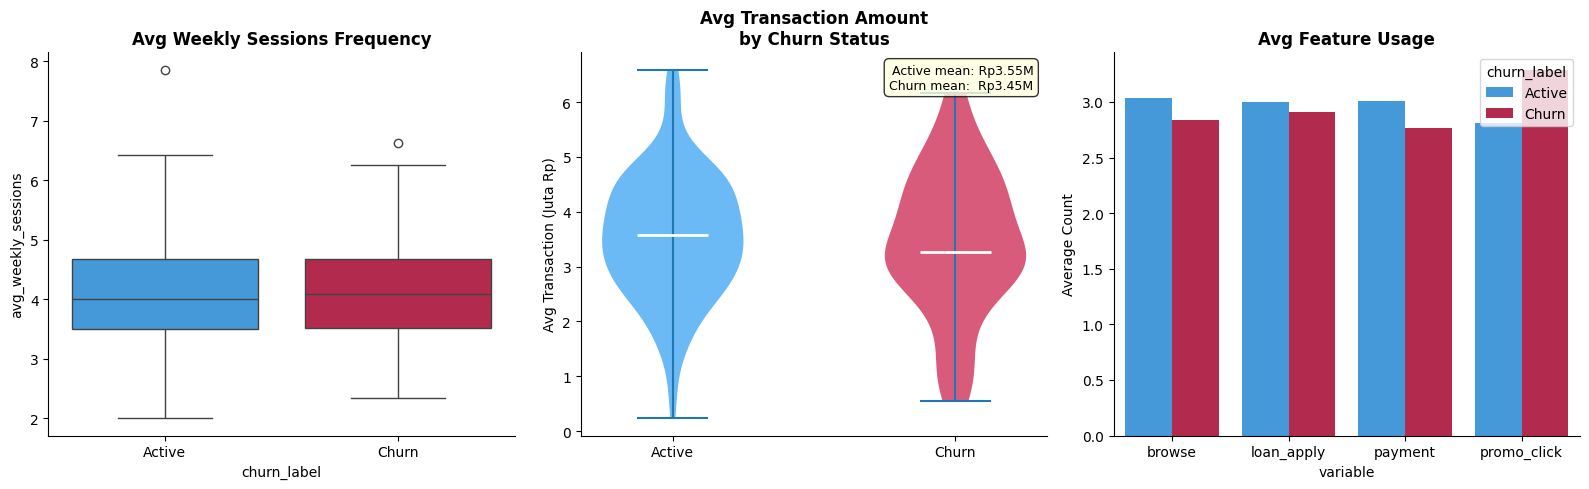

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x="churn_label", y="avg_weekly_sessions", palette=PALETTE, ax=axes[0])
axes[0].set_title("Avg Weekly Sessions Frequency")

ax = axes[1]
data_vio = [df[df['is_churn']==0]['avg_transaction_amount'].dropna()/1e6,
            df[df['is_churn']==1]['avg_transaction_amount'].dropna()/1e6]
vp = ax.violinplot(data_vio, positions=[1, 2], showmedians=True)
for pc, color in zip(vp['bodies'], [C_ACTIVE, C_CHURN]):
    pc.set_facecolor(color); pc.set_alpha(0.7)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax.set_xticks([1,2]); ax.set_xticklabels(['Active', 'Churn'])
ax.set_ylabel('Avg Transaction (Juta Rp)')
ax.set_title('Avg Transaction Amount\nby Churn Status')
means = [d.mean() for d in data_vio]
ax.text(0.97, 0.97,
        f"Active mean: Rp{means[0]:.2f}M\nChurn mean:  Rp{means[1]:.2f}M",
        transform=ax.transAxes, va='top', ha='right', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

feat_cols = ["browse", "loan_apply", "payment", "promo_click"]
feat_means = df.groupby("churn_label")[feat_cols].mean().reset_index().melt(id_vars="churn_label")
sns.barplot(data=feat_means, x="variable", y="value", hue="churn_label", palette=PALETTE, ax=axes[2])
axes[2].set_title("Avg Feature Usage")
axes[2].set_ylabel("Average Count")


plt.tight_layout()
plt.savefig("2_session_and_features.png", dpi=120)
plt.show()

# Insight

**[H0_1] Rejected — Churned Users Actually Open the App More Frequently**

Data: The average weekly sessions of Churn users (**4.19x**) is actually higher than Active users (**4.09x**). The transaction violin plot also shows nearly identical distributions (Active Rp3.55M vs Churn Rp3.45M, less than 3% difference).

Interpretation: Session frequency and transaction amount are **not differentiators of churn**. This is a critical finding. Vanity metrics such as DAU or average transaction value can be misleading if used as the sole indicators of retention. What drives loyalty is not how often users open the app, but what they do once inside.

---

**[H0_2] Supported — The Promo Hunter Behavioral Pattern Is Confirmed**

Data: Churn users click promotions far more frequently (**3.28x**) compared to Active users (**2.81x**), yet use the payment feature less (**2.77x** vs Active **3.01x**) and also make fewer loan applications.

Interpretation: A distinct user segment visits the platform solely to claim discounts or promotions with no intention of becoming a regular borrower. They appear superficially engaged (frequent app opens, high promo clicks) but never build the core habits of the platform: applying for loans and making consistent repayments. Overly aggressive promotional strategies tend to attract exactly this type of user profile.

# 3. Identify Characteristics of Users Likely to Churn
**H0_1:** Incentive-based programs such as Referral attract higher-quality users compared to other acquisition channels.

**H0_2:** Younger users are more financially unstable and therefore more prone to churning.

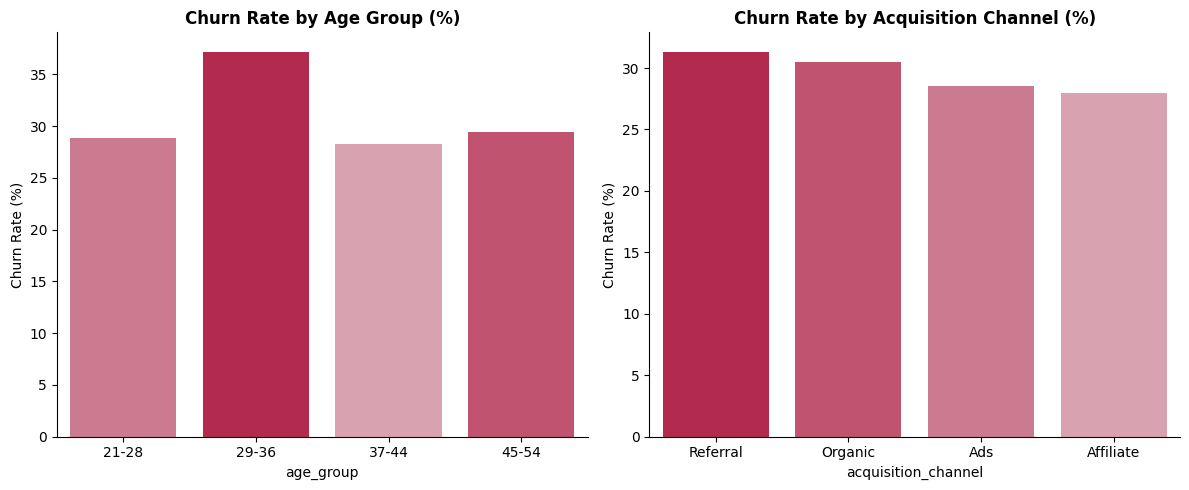

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Group Usia
df_age = df[df["age"] > 0].copy()
df_age["age_group"] = pd.cut(df_age["age"], bins=[20, 28, 36, 44, 55], labels=["21-28", "29-36", "37-44", "45-54"])
age_churn = df_age.groupby("age_group")["is_churn"].mean() * 100

# Membuat gradasi warna agar batang tertinggi mendapat warna paling bold
rank_age = age_churn.argsort().argsort() # Mencari urutan dari nilai terkecil ke terbesar
pal_age = sns.light_palette(C_CHURN, n_colors=len(age_churn) + 2)
colors_age = [pal_age[i + 2] for i in rank_age] # Menyesuaikan warna dengan urutan nilai

sns.barplot(x=age_churn.index, y=age_churn.values, palette=colors_age, ax=axes[0])
axes[0].set_title("Churn Rate by Age Group (%)")
axes[0].set_ylabel("Churn Rate (%)")

# 2. Channel Akuisisi
chan_churn = df.groupby("acquisition_channel")["is_churn"].mean().sort_values(ascending=False) * 100

# Membuat gradasi warna agar batang tertinggi mendapat warna paling bold
rank_chan = chan_churn.argsort().argsort()
pal_chan = sns.light_palette(C_CHURN, n_colors=len(chan_churn) + 2)
colors_chan = [pal_chan[i + 2] for i in rank_chan]

sns.barplot(x=chan_churn.index, y=chan_churn.values, palette=colors_chan, ax=axes[1])
axes[1].set_title("Churn Rate by Acquisition Channel (%)")
axes[1].set_ylabel("Churn Rate (%)")

plt.tight_layout()
plt.savefig("3_churn_characteristics.png", dpi=120)
plt.show()

# Insight

**[H0_1] Rejected — Referral Attracts Low-Quality Users**

Data: Referral has the highest churn rate (31.3%), while Affiliate has the lowest (27.9%).

Interpretation: Users from Referral are likely driven by referral bonuses rather than a real financial need. Affiliate users arrive more organically and demonstrate the strongest loyalty. Incentive-based referral programs do not guarantee user quality and may inflate acquisition numbers without improving long-term retention.

---

**[H0_2] Rejected — Age Is Not a Significant Predictor of Churn**

Data: Churn rate is relatively evenly distributed across all age groups.

Interpretation: This lending product appeals broadly across all age segments. Churn prevention cannot rely on demographic targeting by age. It must be driven entirely by behavioral signals such as inactivity duration, loan frequency, and feature engagement.

# 4. Create Simple Segmentation: High-Risk vs Low-Risk Users
**H0_1:** The first loan experience is the most critical moment. If it fails to impress, users will not return.

**H0_2:** Combining loan count and inactivity duration can accurately map churn risk across the user base.

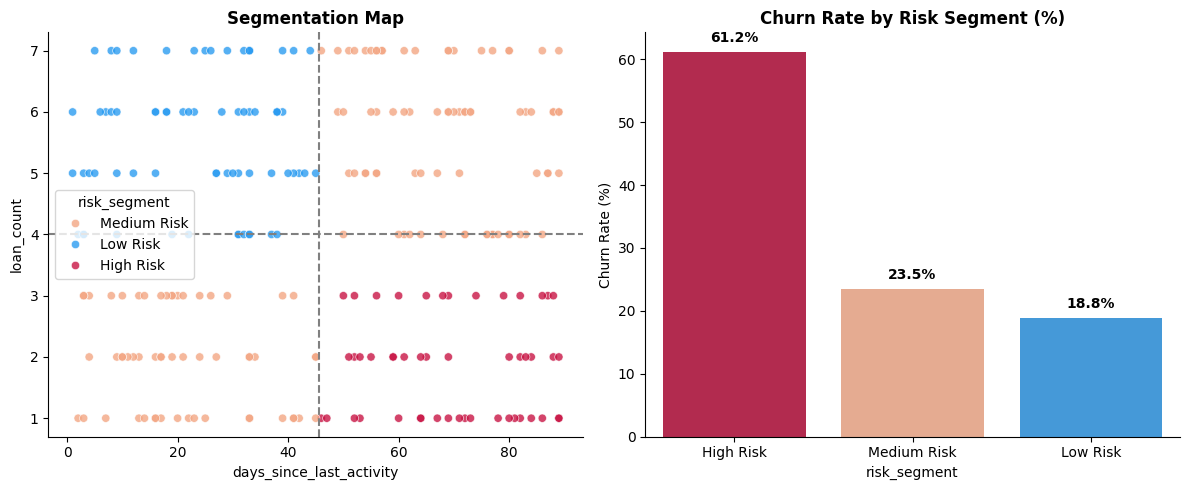

In [26]:
median_days = df["days_since_last_activity"].median()
median_loans = df["loan_count"].median()

def get_risk_segment(row):
    if row["days_since_last_activity"] > median_days and row["loan_count"] < median_loans:
        return "High Risk"
    elif row["days_since_last_activity"] <= median_days and row["loan_count"] >= median_loans:
        return "Low Risk"
    return "Medium Risk"

df["risk_segment"] = df.apply(get_risk_segment, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
risk_palette = {"High Risk": C_CHURN, "Medium Risk": "#f3a683", "Low Risk": C_ACTIVE}

# Segmentation Map
sns.scatterplot(data=df, x="days_since_last_activity", y="loan_count", hue="risk_segment",
                palette=risk_palette, ax=axes[0], alpha=0.8)
axes[0].axvline(median_days, color="gray", linestyle="--")
axes[0].axhline(median_loans, color="gray", linestyle="--")
axes[0].set_title("Segmentation Map")

# Churn Rate by Segment
seg_churn = df.groupby("risk_segment")["is_churn"].mean().reindex(["High Risk", "Medium Risk", "Low Risk"]) * 100
sns.barplot(x=seg_churn.index, y=seg_churn.values, palette=risk_palette, ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', 
                     fontsize=10, fontweight='bold', 
                     xytext=(0, 5), textcoords='offset points')
axes[1].set_title("Churn Rate by Risk Segment (%)")
axes[1].set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("4_segmentation.png", dpi=120)
plt.show()



# Insight

**[H0_1] Supported — The First Loan Is the Moment of Truth**

Data: Users with loan_count = 1 account for the largest proportion of the churn population, with a churn rate of **69.2%** (27 out of 39 users).

Interpretation: The first borrowing experience is the single most decisive factor in determining whether a user will return. If the application process, disbursement speed, or repayment experience falls short of expectations, users will not come back. Converting first-time borrowers into repeat borrowers is the highest-leverage retention opportunity available.

---

**[H0_2] Supported — Risk Segmentation Proves Highly Accurate**

Data: Combining inactivity duration and loan count produces three clearly separated risk segments:

- **High Risk** (inactive > 46 days & loan_count < 4): **61.2%** churn rate
- **Medium Risk** (one condition met): **23.5%** churn rate
- **Low Risk** (inactive <= 46 days & loan_count >= 4): **18.8%** churn rate

Interpretation: The three segments show a 3x difference in churn rate between High and Low Risk. This segmentation is immediately actionable. The business team can directly prioritize retention budget and outreach interventions for the High Risk group, while applying lighter nurturing campaigns for Medium Risk users.